Transformer Sequence-to-Sequence
untuk Klasifikasi Sinyal EKG
dalam Deteksi Aritmia Berbasis Input Sinyal

0. Import & Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 116.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.


In [3]:
import time
import os
import numpy as np
import wfdb
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import resample
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)


1. Konfigurasi Dasar

In [4]:
FS = 250
WINDOW = 2000
EPOCHS = 30
BATCH = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_DIR = "/content/drive/MyDrive/Data TA"


2. Label Mapping

In [5]:
LABEL_MAP_MITDB = {
    "N": 0,      # Normal
    "V": 1      # Ventricular ectopic beat
}


In [6]:
LABEL_MAP_AFDB = {
    "N": 0,      # Normal
    "AFIB": 1   # Atrial Fibrillation
}


In [7]:
LABEL_MAP_VFDB = {
    "VF": 0,      # Ventricular Fibrillation
    "VT": 1     # Ventricular Tachycardia
}


3. Fungsi Umum

In [8]:
def normalize(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-8)


4. Load MITDB (Beat Classification)

In [9]:
def load_mitdb():
    X, y = [], []
    path = f"{BASE_DIR}/mit-bih-arrhythmia-database-1.0.0"

    for rec in os.listdir(path):
        if not rec.endswith(".dat"): continue

        r = wfdb.rdrecord(os.path.join(path, rec[:-4]))
        a = wfdb.rdann(os.path.join(path, rec[:-4]), "atr")

        sig = r.p_signal[:,0]
        fs = int(r.fs)
        if fs != FS:
            sig = resample(sig, int(len(sig)*FS/fs))

        for s, sym in zip(a.sample, a.symbol):
            if sym not in LABEL_MAP_MITDB: continue

            idx = int(s * FS / fs)
            if idx-WINDOW//2 < 0 or idx+WINDOW//2 > len(sig): continue

            seg = normalize(sig[idx-WINDOW//2:idx+WINDOW//2])
            X.append(seg)
            y.append(LABEL_MAP_MITDB[sym])

    return np.array(X), np.array(y)


5. Load AFDB (Rhythm)

In [10]:
def load_afdb():
    X, y = [], []
    path = f"{BASE_DIR}/files"

    for rec in os.listdir(path):
        if not rec.endswith(".dat"): continue

        sig, fields = wfdb.rdsamp(os.path.join(path, rec[:-4]))
        ann = wfdb.rdann(os.path.join(path, rec[:-4]), "atr")

        signal = sig[:,0]
        fs = int(fields["fs"])
        if fs != FS:
            signal = resample(signal, int(len(signal)*FS/fs))

        for i in range(len(ann.sample)-1):
            label = ann.aux_note[i].strip("(")
            if label not in LABEL_MAP_AFDB: continue

            start = int(ann.sample[i]*FS/fs)
            if start+WINDOW > len(signal): continue

            seg = normalize(signal[start:start+WINDOW])
            X.append(seg)
            y.append(LABEL_MAP_AFDB[label])

    return np.array(X), np.array(y)


6. Load VFDB

In [11]:
def load_vfdb():
    X, y = [], []
    path = f"{BASE_DIR}/mit-bih-malignant-ventricular-ectopy-database-1.0.0"

    for rec in os.listdir(path):
        if not rec.endswith(".dat"):
            continue

        record = rec.replace(".dat", "")

        try:
            sig, fields = wfdb.rdsamp(os.path.join(path, record))
            ann = wfdb.rdann(os.path.join(path, record), "atr")
        except Exception as e:
            print("Skip:", record, e)
            continue

        fs = int(fields["fs"])
        signal = sig[:, 0]

        if fs != FS:
            signal = resample(signal, int(len(signal) * FS / fs))

        for i, label in enumerate(ann.aux_note):

            label = label.strip().upper()

            if "VF" in label:
                cls = 0
            elif "VT" in label:
                cls = 1
            else:
                continue

            idx = int(ann.sample[i] * 250 / fs)

            if idx - WINDOW//2 < 0 or idx + WINDOW//2 > len(signal):
                continue

            segment = signal[idx - WINDOW//2 : idx + WINDOW//2]
            X.append(segment)
            y.append(cls)

    return np.array(X), np.array(y)


7. Balancing

In [12]:
def balance_classes(X, y):
    classes, counts = np.unique(y, return_counts=True)
    min_count = counts.min()

    Xb, yb = [], []
    for c in classes:
        idx = np.where(y == c)[0][:min_count]
        Xb.append(X[idx])
        yb.append(y[idx])

    Xb = np.concatenate(Xb)
    yb = np.concatenate(yb)

    perm = np.random.permutation(len(yb))
    return Xb[perm], yb[perm]


8. Samples Checking

In [13]:
# MITDB

X_mit, y_mit = load_mitdb()
print("Before balance:", np.unique(y_mit, return_counts=True))

X_mit, y_mit = balance_classes(X_mit, y_mit)

print("After balance:", np.unique(y_mit, return_counts=True))



Before balance: (array([0, 1]), array([74708,  7106]))
After balance: (array([0, 1]), array([7106, 7106]))


In [14]:
# AFDB

X_af, y_af = load_afdb()
print("Before balance:", np.unique(y_af, return_counts=True))

X_af, y_af = balance_classes(X_af, y_af)

print("After balance:", np.unique(y_af, return_counts=True))



Before balance: (array([0, 1]), array([274, 283]))
After balance: (array([0, 1]), array([274, 274]))


In [15]:
# VFDB

X_vf, y_vf = load_vfdb()
print("Before balance:", np.unique(y_vf, return_counts=True))

X_vf, y_vf = balance_classes(X_vf, y_vf)

print("After balance:", np.unique(y_vf, return_counts=True))



Before balance: (array([0, 1]), array([111,  98]))
After balance: (array([0, 1]), array([98, 98]))


9. Dataset & Loader

In [16]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


10. Model (Seq2Seq Transformer)

In [17]:
class ECGSeq2Seq(nn.Module):
    def __init__(self, n_class):
        super().__init__()

        self.nn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        # 2000 → 500 length, channel 64
        self.proj = nn.Linear(64, 128)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=4,
            batch_first=True
        )

        self.enc = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(128, n_class)

    def forward(self, x):
        # x: (batch, 2000)
        x = x.unsqueeze(1)          # (batch, 1, 2000)
        x = self.nn(x)              # (batch, 64, 500)
        x = x.permute(0, 2, 1)      # (batch, 500, 64)
        x = self.proj(x)            # (batch, 500, 128)
        x = self.enc(x)             # (batch, 500, 128)
        x = x.mean(dim=1)           # global average pooling
        return self.fc(x)


11. Train + Evaluation

In [18]:
def train_one_fold(
    X_train,
    y_train,
    X_val,
    y_val,
    title,
    fold
):

    print("\n========================================")
    print(f"{title} - FOLD {fold}")
    print("========================================")

    # ==================================================
    # DataLoader
    # ==================================================

    train_loader = DataLoader(
        ECGDataset(X_train, y_train),
        BATCH,
        True
    )

    val_loader = DataLoader(
        ECGDataset(X_val, y_val),
        BATCH
    )

    # ==================================================
    # Pembuatan Model
    # ==================================================

    model_start = time.perf_counter()

    model = ECGSeq2Seq(
        len(np.unique(y_train))
    ).to(DEVICE)

    model_creation_time = (
        time.perf_counter() - model_start
    )

    print(
        f"Model creation time: "
        f"{model_creation_time:.4f} seconds"
    )

    # ==================================================
    # Learning Rate
    # ==================================================

    if title == "MITDB":
        lr = 1e-4

    elif title == "AFDB":
        lr = 5e-5

    else:
        lr = 1e-5

    # ==================================================
    # Optimizer
    # ==================================================

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    loss_fn = nn.CrossEntropyLoss()

    # ==================================================
    # History
    # ==================================================

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    # ==================================================
    # Training
    # ==================================================

    training_start = time.perf_counter()

    for epoch in range(EPOCHS):

        # ----------------------------------------------
        # TRAINING
        # ----------------------------------------------

        model.train()

        train_loss_total = 0
        train_correct = 0
        train_total = 0

        for xb, yb in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            opt.zero_grad()

            output = model(xb)

            loss = loss_fn(
                output,
                yb
            )

            loss.backward()

            opt.step()

            train_loss_total += (
                loss.item() * yb.size(0)
            )

            prediction = torch.argmax(
                output,
                dim=1
            )

            train_correct += (
                prediction == yb
            ).sum().item()

            train_total += yb.size(0)

        train_loss = (
            train_loss_total /
            train_total
        )

        train_acc = (
            train_correct /
            train_total
        )

        # ----------------------------------------------
        # VALIDATION
        # ----------------------------------------------

        model.eval()

        val_loss_total = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for xb, yb in val_loader:

                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                output = model(xb)

                loss = loss_fn(
                    output,
                    yb
                )

                val_loss_total += (
                    loss.item() * yb.size(0)
                )

                prediction = torch.argmax(
                    output,
                    dim=1
                )

                val_correct += (
                    prediction == yb
                ).sum().item()

                val_total += yb.size(0)

        val_loss = (
            val_loss_total /
            val_total
        )

        val_acc = (
            val_correct /
            val_total
        )

        # ----------------------------------------------
        # Simpan History
        # ----------------------------------------------

        train_losses.append(
            train_loss
        )

        val_losses.append(
            val_loss
        )

        train_accs.append(
            train_acc
        )

        val_accs.append(
            val_acc
        )

        print(
            f"Fold {fold} | "
            f"Epoch [{epoch + 1}/{EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    training_time = (
        time.perf_counter()
        - training_start
    )

    # ==================================================
    # Hasil Fold
    # ==================================================

    best_val_acc = max(
        val_accs
    )

    best_epoch = (
        np.argmax(val_accs) + 1
    )

    print("\n----------------------------------------")
    print(f"Fold {fold} Result")
    print("----------------------------------------")

    print(
        f"Best Validation Accuracy : "
        f"{best_val_acc:.4f}"
    )

    print(
        f"Best Epoch               : "
        f"{best_epoch}"
    )

    print(
        f"Training Time            : "
        f"{training_time:.2f} seconds"
    )

    # ==================================================
    # Grafik Accuracy
    # ==================================================

    epochs = range(
        1,
        EPOCHS + 1
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        epochs,
        train_accs,
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        val_accs,
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title(
        f"{title} - Fold {fold}\n"
        "Training vs Validation Accuracy"
    )

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

    # ==================================================
    # Grafik Loss
    # ==================================================

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        epochs,
        train_losses,
        label="Training Loss"
    )

    plt.plot(
        epochs,
        val_losses,
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(
        f"{title} - Fold {fold}\n"
        "Training vs Validation Loss"
    )

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

    # ==================================================
    # Return
    # ==================================================

    return {
        "model": model,
        "fold": fold,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "model_creation_time": model_creation_time,
        "training_time": training_time
    }


# ======================================================
# TRAIN + EVALUATION
# ======================================================

def train_and_evaluate(
    X,
    y,
    title
):

    print("\n")
    print("########################################")
    print(f"DATASET: {title}")
    print("########################################")

    # ==================================================
    # 1. Pisahkan TEST SET
    # ==================================================

    X_train_cv, X_test, y_train_cv, y_test = (
        train_test_split(
            X,
            y,
            test_size=0.2,
            stratify=y,
            random_state=42
        )
    )

    print(
        f"Training + CV data : "
        f"{len(X_train_cv)}"
    )

    print(
        f"Test data          : "
        f"{len(X_test)}"
    )

    # ==================================================
    # 2. 5-FOLD CROSS VALIDATION
    # ==================================================

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    fold_results = []

    # ==================================================
    # 3. Jalankan Fold 1-5
    # ==================================================

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(
            X_train_cv,
            y_train_cv
        ),
        start=1
    ):

        X_train = X_train_cv[
            train_idx
        ]

        y_train = y_train_cv[
            train_idx
        ]

        X_val = X_train_cv[
            val_idx
        ]

        y_val = y_train_cv[
            val_idx
        ]

        result = train_one_fold(
            X_train,
            y_train,
            X_val,
            y_val,
            title,
            fold
        )

        fold_results.append(
            result
        )

    # ==================================================
    # 4. Pilih Fold Terbaik
    # ==================================================

    best_result = max(
        fold_results,
        key=lambda x: x["best_val_acc"]
    )

    best_model = best_result[
        "model"
    ]

    best_fold = best_result[
        "fold"
    ]

    best_val_acc = best_result[
        "best_val_acc"
    ]

    print("\n")
    print("########################################")
    print("BEST FOLD")
    print("########################################")

    print(
        f"Best Fold              : "
        f"{best_fold}"
    )

    print(
        f"Best Validation Acc    : "
        f"{best_val_acc:.4f}"
    )

    print(
        f"Best Epoch             : "
        f"{best_result['best_epoch']}"
    )

    # ==================================================
    # 5. TEST MODEL TERBAIK
    # ==================================================

    print("\n")
    print("########################################")
    print("FINAL TEST")
    print("########################################")

    test_loader = DataLoader(
        ECGDataset(
            X_test,
            y_test
        ),
        BATCH
    )

    best_model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for xb, yb in test_loader:

            xb = xb.to(DEVICE)

            output = best_model(
                xb
            )

            probability = torch.softmax(
                output,
                dim=1
            )

            prediction = torch.argmax(
                probability,
                dim=1
            )

            y_true.extend(
                yb.cpu().numpy()
            )

            y_pred.extend(
                prediction.cpu().numpy()
            )

            y_prob.extend(
                probability[:, 1]
                .cpu()
                .numpy()
            )

    # ==================================================
    # 6. Metrics
    # ==================================================

    acc = accuracy_score(
        y_true,
        y_pred
    )

    rec = recall_score(
        y_true,
        y_pred,
        average="macro"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    spec = recall_score(
        y_true,
        y_pred,
        average="macro"
    )

    auc = roc_auc_score(
        y_true,
        np.array(y_prob),
        multi_class="ovr"
    )

    print(
        f"\nBest Fold = {best_fold}"
    )

    print(
        f"Accuracy     : {acc:.4f}"
    )

    print(
        f"Recall       : {rec:.4f}"
    )

    print(
        f"F1-score     : {f1:.4f}"
    )

    print(
        f"Specificity  : {spec:.4f}"
    )

    print(
        f"ROC-AUC      : {auc:.4f}"
    )

    # ==================================================
    # 7. Confusion Matrix
    # ==================================================

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(
        figsize=(6, 5)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"{title} - Best Fold {best_fold}\n"
        "Confusion Matrix"
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "True"
    )

    plt.tight_layout()

    plt.show()

    # ==================================================
    # Return
    # ==================================================

    return {
        "best_fold": best_fold,
        "best_val_acc": best_val_acc,
        "test_accuracy": acc,
        "test_recall": rec,
        "test_f1": f1,
        "test_specificity": spec,
        "test_auc": auc
    }



########################################
DATASET: MITDB
########################################
Training + CV data : 11369
Test data          : 2843

MITDB - FOLD 1
Model creation time: 0.2927 seconds
Fold 1 | Epoch [1/30] | Train Loss: 0.2164 | Val Loss: 0.0489 | Train Acc: 0.9105 | Val Acc: 0.9864
Fold 1 | Epoch [2/30] | Train Loss: 0.0546 | Val Loss: 0.0379 | Train Acc: 0.9812 | Val Acc: 0.9886
Fold 1 | Epoch [3/30] | Train Loss: 0.0392 | Val Loss: 0.0272 | Train Acc: 0.9882 | Val Acc: 0.9899
Fold 1 | Epoch [4/30] | Train Loss: 0.0313 | Val Loss: 0.0672 | Train Acc: 0.9896 | Val Acc: 0.9793
Fold 1 | Epoch [5/30] | Train Loss: 0.0379 | Val Loss: 0.0195 | Train Acc: 0.9876 | Val Acc: 0.9938
Fold 1 | Epoch [6/30] | Train Loss: 0.0209 | Val Loss: 0.0178 | Train Acc: 0.9936 | Val Acc: 0.9956
Fold 1 | Epoch [7/30] | Train Loss: 0.0229 | Val Loss: 0.0153 | Train Acc: 0.9921 | Val Acc: 0.9956
Fold 1 | Epoch [8/30] | Train Loss: 0.0155 | Val Loss: 0.0147 | Train Acc: 0.9946 | Val Acc: 0.9

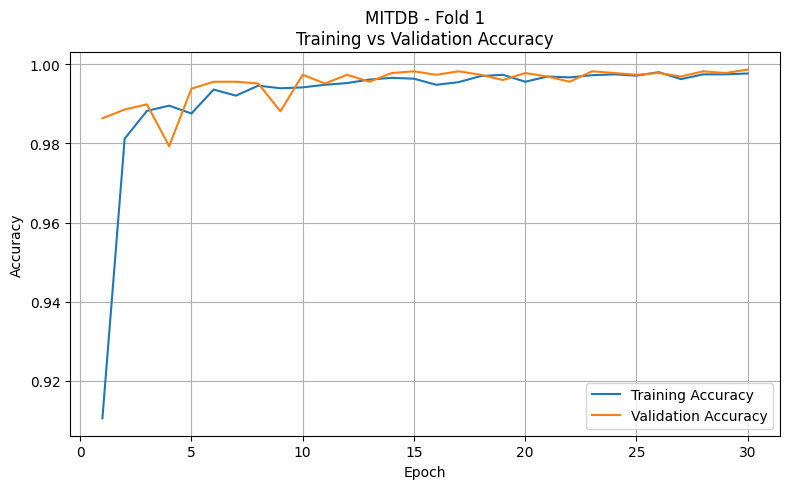

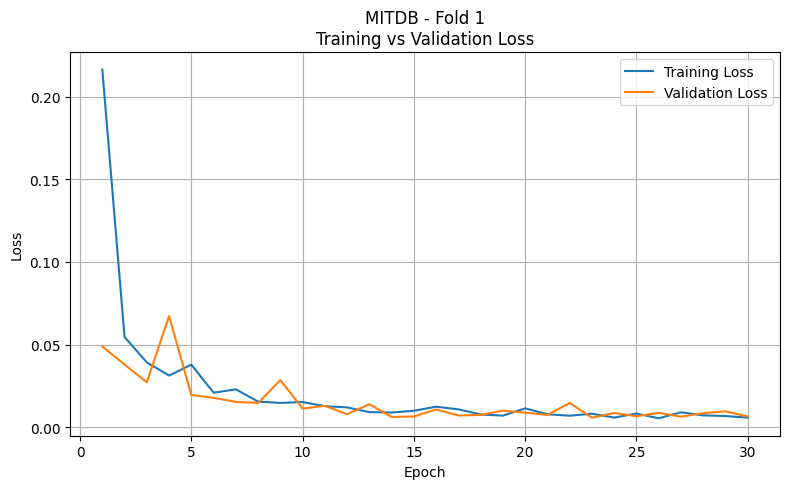


MITDB - FOLD 2
Model creation time: 0.0121 seconds
Fold 2 | Epoch [1/30] | Train Loss: 0.2251 | Val Loss: 0.0634 | Train Acc: 0.8998 | Val Acc: 0.9763
Fold 2 | Epoch [2/30] | Train Loss: 0.0477 | Val Loss: 0.0464 | Train Acc: 0.9845 | Val Acc: 0.9833
Fold 2 | Epoch [3/30] | Train Loss: 0.0341 | Val Loss: 0.0253 | Train Acc: 0.9888 | Val Acc: 0.9903
Fold 2 | Epoch [4/30] | Train Loss: 0.0274 | Val Loss: 0.0171 | Train Acc: 0.9908 | Val Acc: 0.9938
Fold 2 | Epoch [5/30] | Train Loss: 0.0286 | Val Loss: 0.0220 | Train Acc: 0.9904 | Val Acc: 0.9912
Fold 2 | Epoch [6/30] | Train Loss: 0.0199 | Val Loss: 0.0134 | Train Acc: 0.9933 | Val Acc: 0.9960
Fold 2 | Epoch [7/30] | Train Loss: 0.0198 | Val Loss: 0.0182 | Train Acc: 0.9938 | Val Acc: 0.9930
Fold 2 | Epoch [8/30] | Train Loss: 0.0180 | Val Loss: 0.0108 | Train Acc: 0.9938 | Val Acc: 0.9960
Fold 2 | Epoch [9/30] | Train Loss: 0.0156 | Val Loss: 0.0169 | Train Acc: 0.9948 | Val Acc: 0.9947
Fold 2 | Epoch [10/30] | Train Loss: 0.0184 | Va

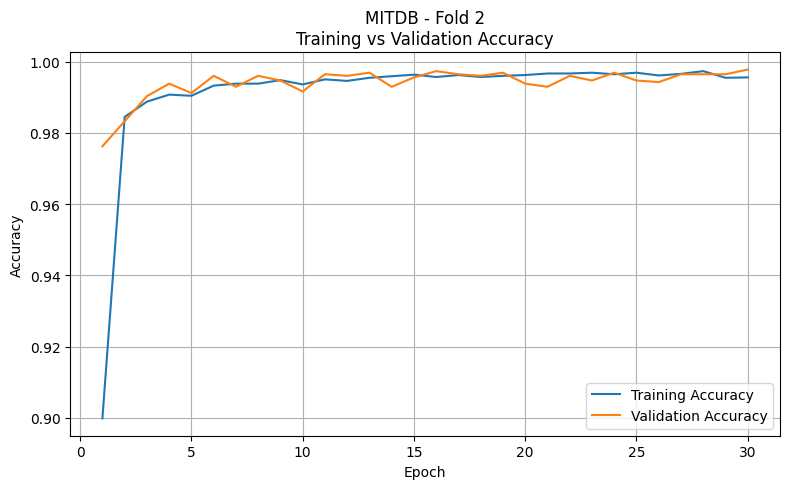

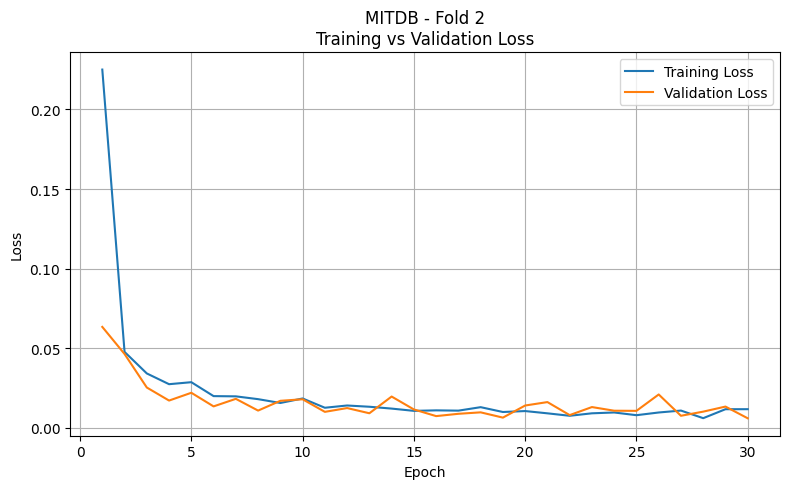


MITDB - FOLD 3
Model creation time: 0.0163 seconds
Fold 3 | Epoch [1/30] | Train Loss: 0.2094 | Val Loss: 0.0555 | Train Acc: 0.9009 | Val Acc: 0.9820
Fold 3 | Epoch [2/30] | Train Loss: 0.0605 | Val Loss: 0.0299 | Train Acc: 0.9792 | Val Acc: 0.9899
Fold 3 | Epoch [3/30] | Train Loss: 0.0363 | Val Loss: 0.0210 | Train Acc: 0.9871 | Val Acc: 0.9925
Fold 3 | Epoch [4/30] | Train Loss: 0.0296 | Val Loss: 0.0181 | Train Acc: 0.9896 | Val Acc: 0.9947
Fold 3 | Epoch [5/30] | Train Loss: 0.0259 | Val Loss: 0.0163 | Train Acc: 0.9903 | Val Acc: 0.9938
Fold 3 | Epoch [6/30] | Train Loss: 0.0213 | Val Loss: 0.0121 | Train Acc: 0.9926 | Val Acc: 0.9960
Fold 3 | Epoch [7/30] | Train Loss: 0.0224 | Val Loss: 0.0147 | Train Acc: 0.9918 | Val Acc: 0.9956
Fold 3 | Epoch [8/30] | Train Loss: 0.0161 | Val Loss: 0.0109 | Train Acc: 0.9943 | Val Acc: 0.9960
Fold 3 | Epoch [9/30] | Train Loss: 0.0153 | Val Loss: 0.0103 | Train Acc: 0.9952 | Val Acc: 0.9956
Fold 3 | Epoch [10/30] | Train Loss: 0.0131 | Va

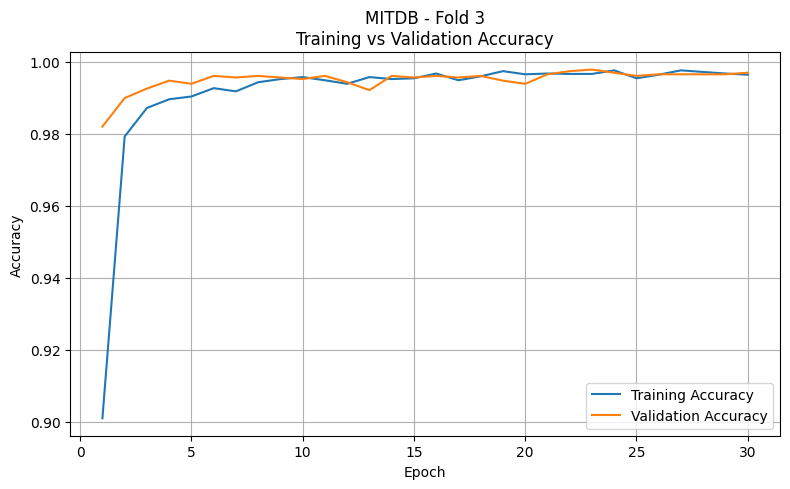

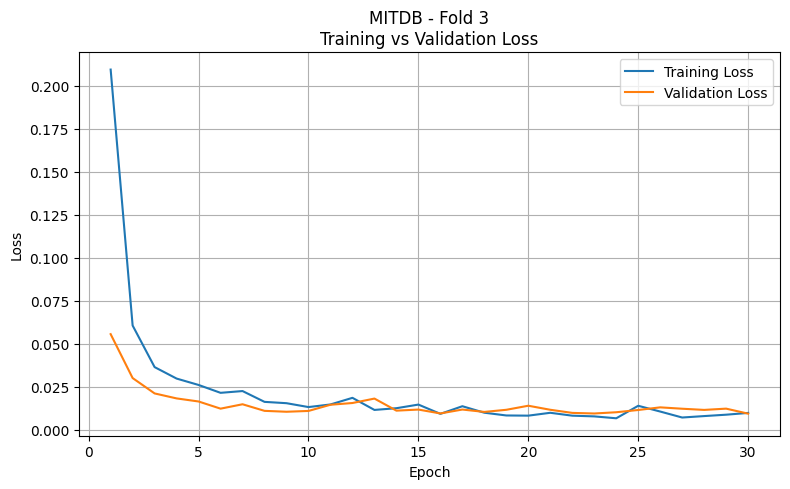


MITDB - FOLD 4
Model creation time: 0.0112 seconds
Fold 4 | Epoch [1/30] | Train Loss: 0.2223 | Val Loss: 0.0736 | Train Acc: 0.9062 | Val Acc: 0.9763
Fold 4 | Epoch [2/30] | Train Loss: 0.0511 | Val Loss: 0.0491 | Train Acc: 0.9843 | Val Acc: 0.9864
Fold 4 | Epoch [3/30] | Train Loss: 0.0396 | Val Loss: 0.0465 | Train Acc: 0.9879 | Val Acc: 0.9855
Fold 4 | Epoch [4/30] | Train Loss: 0.0274 | Val Loss: 0.0314 | Train Acc: 0.9909 | Val Acc: 0.9912
Fold 4 | Epoch [5/30] | Train Loss: 0.0215 | Val Loss: 0.0287 | Train Acc: 0.9930 | Val Acc: 0.9899
Fold 4 | Epoch [6/30] | Train Loss: 0.0197 | Val Loss: 0.0353 | Train Acc: 0.9938 | Val Acc: 0.9877
Fold 4 | Epoch [7/30] | Train Loss: 0.0178 | Val Loss: 0.0239 | Train Acc: 0.9932 | Val Acc: 0.9921
Fold 4 | Epoch [8/30] | Train Loss: 0.0151 | Val Loss: 0.0272 | Train Acc: 0.9940 | Val Acc: 0.9934
Fold 4 | Epoch [9/30] | Train Loss: 0.0175 | Val Loss: 0.0207 | Train Acc: 0.9943 | Val Acc: 0.9930
Fold 4 | Epoch [10/30] | Train Loss: 0.0128 | Va

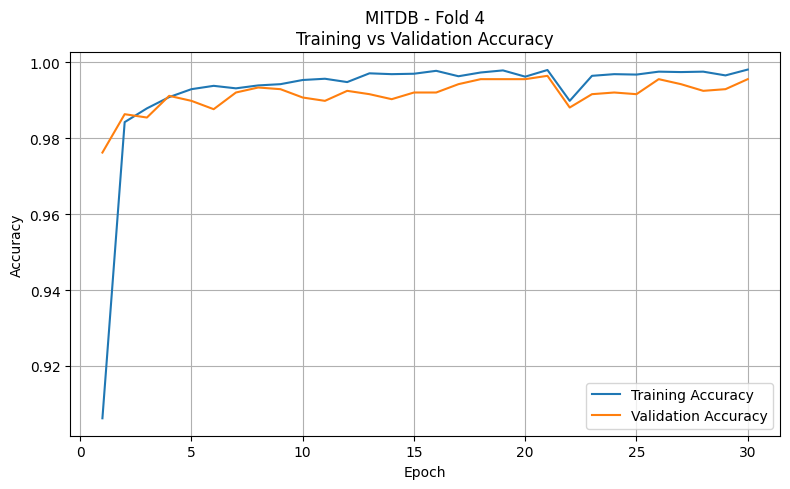

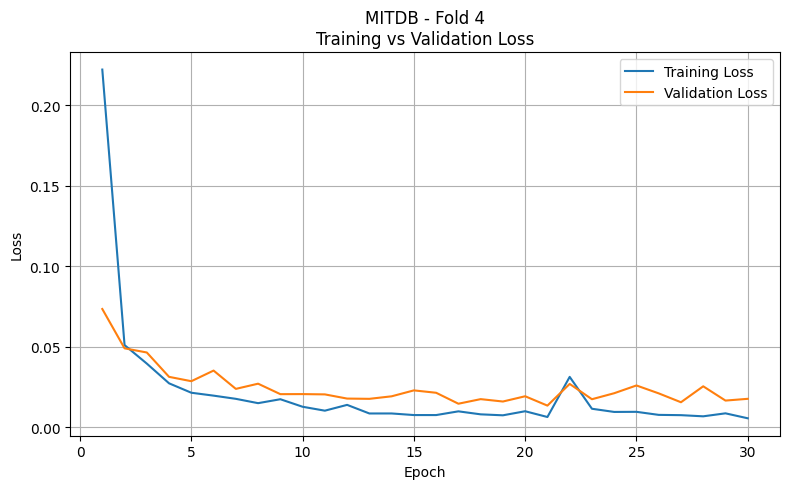


MITDB - FOLD 5
Model creation time: 0.0113 seconds
Fold 5 | Epoch [1/30] | Train Loss: 0.1916 | Val Loss: 0.1588 | Train Acc: 0.9164 | Val Acc: 0.9564
Fold 5 | Epoch [2/30] | Train Loss: 0.0398 | Val Loss: 0.0448 | Train Acc: 0.9860 | Val Acc: 0.9811
Fold 5 | Epoch [3/30] | Train Loss: 0.0356 | Val Loss: 0.0291 | Train Acc: 0.9869 | Val Acc: 0.9899
Fold 5 | Epoch [4/30] | Train Loss: 0.0276 | Val Loss: 0.0304 | Train Acc: 0.9905 | Val Acc: 0.9890
Fold 5 | Epoch [5/30] | Train Loss: 0.0225 | Val Loss: 0.0511 | Train Acc: 0.9925 | Val Acc: 0.9793
Fold 5 | Epoch [6/30] | Train Loss: 0.0238 | Val Loss: 0.0173 | Train Acc: 0.9914 | Val Acc: 0.9930
Fold 5 | Epoch [7/30] | Train Loss: 0.0190 | Val Loss: 0.0126 | Train Acc: 0.9933 | Val Acc: 0.9952
Fold 5 | Epoch [8/30] | Train Loss: 0.0165 | Val Loss: 0.0248 | Train Acc: 0.9935 | Val Acc: 0.9894
Fold 5 | Epoch [9/30] | Train Loss: 0.0208 | Val Loss: 0.0152 | Train Acc: 0.9922 | Val Acc: 0.9921
Fold 5 | Epoch [10/30] | Train Loss: 0.0145 | Va

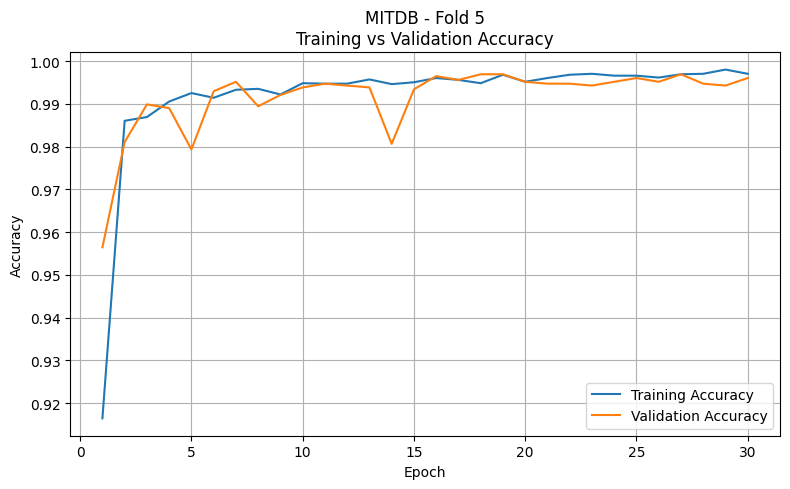

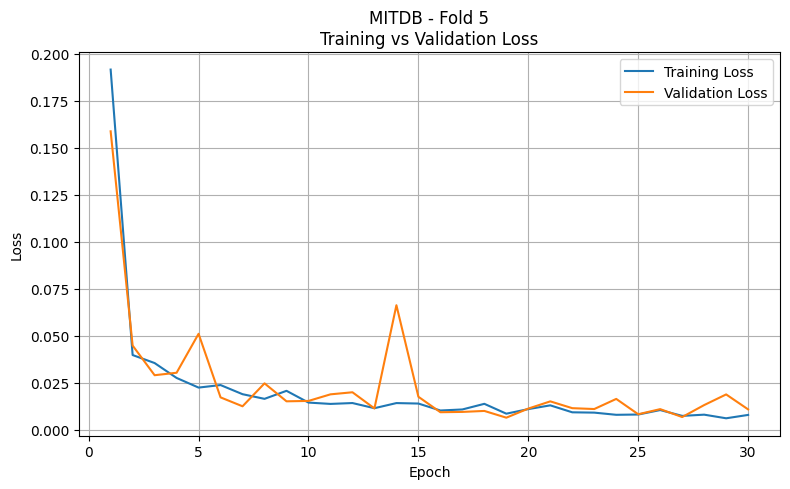



########################################
BEST FOLD
########################################
Best Fold              : 1
Best Validation Acc    : 0.9987
Best Epoch             : 30


########################################
FINAL TEST
########################################

Best Fold = 1
Accuracy     : 0.9965
Recall       : 0.9965
F1-score     : 0.9965
Specificity  : 0.9965
ROC-AUC      : 0.9998


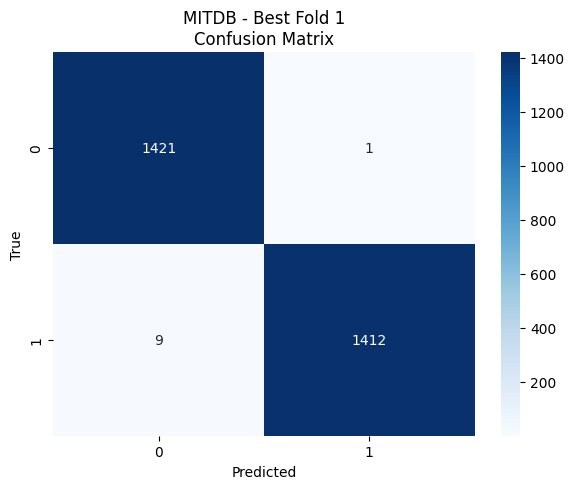



########################################
DATASET: AFDB
########################################
Training + CV data : 438
Test data          : 110

AFDB - FOLD 1
Model creation time: 0.0118 seconds
Fold 1 | Epoch [1/30] | Train Loss: 0.7540 | Val Loss: 0.7341 | Train Acc: 0.4543 | Val Acc: 0.5000
Fold 1 | Epoch [2/30] | Train Loss: 0.7126 | Val Loss: 0.7055 | Train Acc: 0.4943 | Val Acc: 0.4886
Fold 1 | Epoch [3/30] | Train Loss: 0.7022 | Val Loss: 0.7027 | Train Acc: 0.5286 | Val Acc: 0.4886
Fold 1 | Epoch [4/30] | Train Loss: 0.6955 | Val Loss: 0.7172 | Train Acc: 0.5143 | Val Acc: 0.5000
Fold 1 | Epoch [5/30] | Train Loss: 0.6959 | Val Loss: 0.6973 | Train Acc: 0.5286 | Val Acc: 0.4886
Fold 1 | Epoch [6/30] | Train Loss: 0.6822 | Val Loss: 0.6957 | Train Acc: 0.5686 | Val Acc: 0.5114
Fold 1 | Epoch [7/30] | Train Loss: 0.6773 | Val Loss: 0.6933 | Train Acc: 0.5800 | Val Acc: 0.5341
Fold 1 | Epoch [8/30] | Train Loss: 0.6732 | Val Loss: 0.6877 | Train Acc: 0.5943 | Val Acc: 0.5568
F

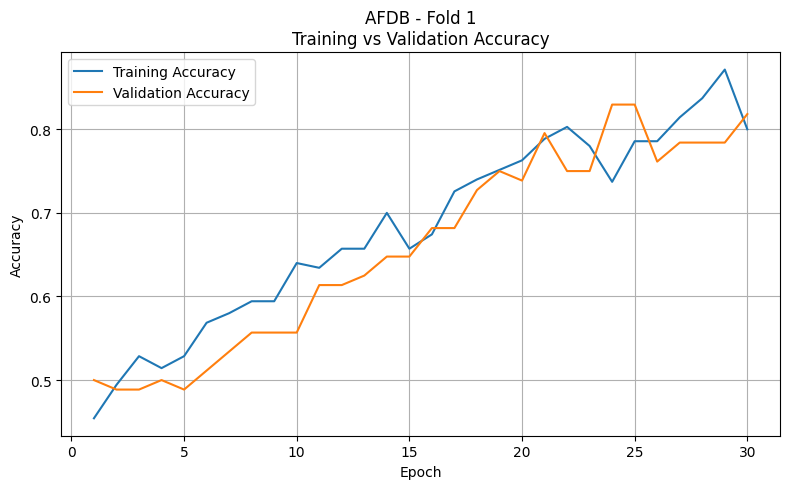

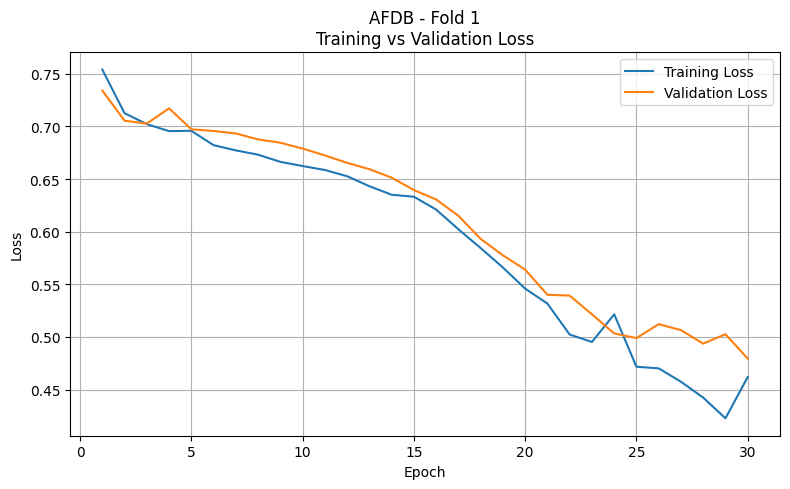


AFDB - FOLD 2
Model creation time: 0.0177 seconds
Fold 2 | Epoch [1/30] | Train Loss: 0.6987 | Val Loss: 0.6936 | Train Acc: 0.5057 | Val Acc: 0.4659
Fold 2 | Epoch [2/30] | Train Loss: 0.6843 | Val Loss: 0.6877 | Train Acc: 0.5657 | Val Acc: 0.4773
Fold 2 | Epoch [3/30] | Train Loss: 0.6798 | Val Loss: 0.6854 | Train Acc: 0.5429 | Val Acc: 0.5227
Fold 2 | Epoch [4/30] | Train Loss: 0.6924 | Val Loss: 0.6800 | Train Acc: 0.5229 | Val Acc: 0.4886
Fold 2 | Epoch [5/30] | Train Loss: 0.6640 | Val Loss: 0.6761 | Train Acc: 0.6314 | Val Acc: 0.5909
Fold 2 | Epoch [6/30] | Train Loss: 0.6584 | Val Loss: 0.6762 | Train Acc: 0.6286 | Val Acc: 0.6023
Fold 2 | Epoch [7/30] | Train Loss: 0.6491 | Val Loss: 0.6655 | Train Acc: 0.6343 | Val Acc: 0.5568
Fold 2 | Epoch [8/30] | Train Loss: 0.6473 | Val Loss: 0.6546 | Train Acc: 0.6086 | Val Acc: 0.6136
Fold 2 | Epoch [9/30] | Train Loss: 0.6300 | Val Loss: 0.6465 | Train Acc: 0.6771 | Val Acc: 0.6364
Fold 2 | Epoch [10/30] | Train Loss: 0.6226 | Val

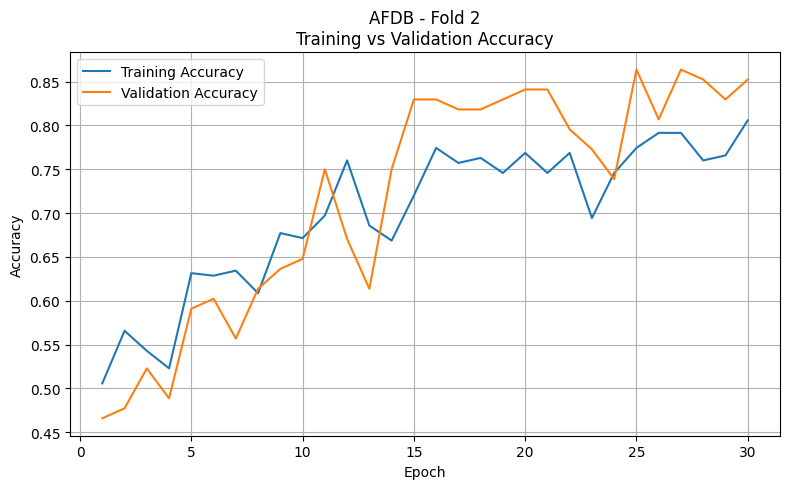

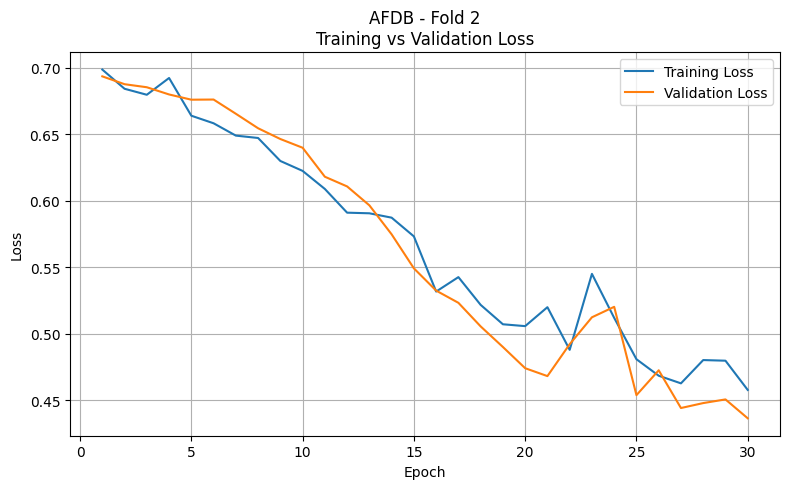


AFDB - FOLD 3
Model creation time: 0.0160 seconds
Fold 3 | Epoch [1/30] | Train Loss: 0.7216 | Val Loss: 0.6998 | Train Acc: 0.4600 | Val Acc: 0.4773
Fold 3 | Epoch [2/30] | Train Loss: 0.6991 | Val Loss: 0.6967 | Train Acc: 0.4629 | Val Acc: 0.5114
Fold 3 | Epoch [3/30] | Train Loss: 0.6907 | Val Loss: 0.6924 | Train Acc: 0.5429 | Val Acc: 0.5000
Fold 3 | Epoch [4/30] | Train Loss: 0.6935 | Val Loss: 0.6863 | Train Acc: 0.5229 | Val Acc: 0.5341
Fold 3 | Epoch [5/30] | Train Loss: 0.6788 | Val Loss: 0.6900 | Train Acc: 0.5829 | Val Acc: 0.5568
Fold 3 | Epoch [6/30] | Train Loss: 0.6768 | Val Loss: 0.6764 | Train Acc: 0.5943 | Val Acc: 0.5682
Fold 3 | Epoch [7/30] | Train Loss: 0.6704 | Val Loss: 0.6724 | Train Acc: 0.5914 | Val Acc: 0.5682
Fold 3 | Epoch [8/30] | Train Loss: 0.6669 | Val Loss: 0.6653 | Train Acc: 0.5971 | Val Acc: 0.5909
Fold 3 | Epoch [9/30] | Train Loss: 0.6594 | Val Loss: 0.6586 | Train Acc: 0.6086 | Val Acc: 0.5909
Fold 3 | Epoch [10/30] | Train Loss: 0.6557 | Val

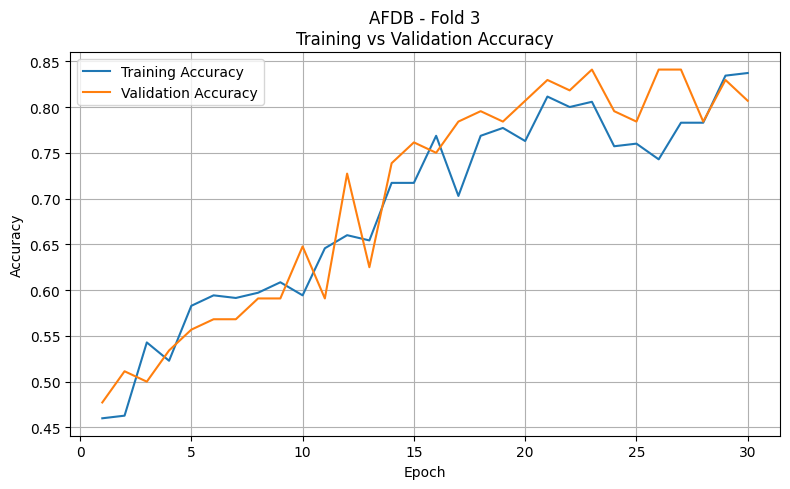

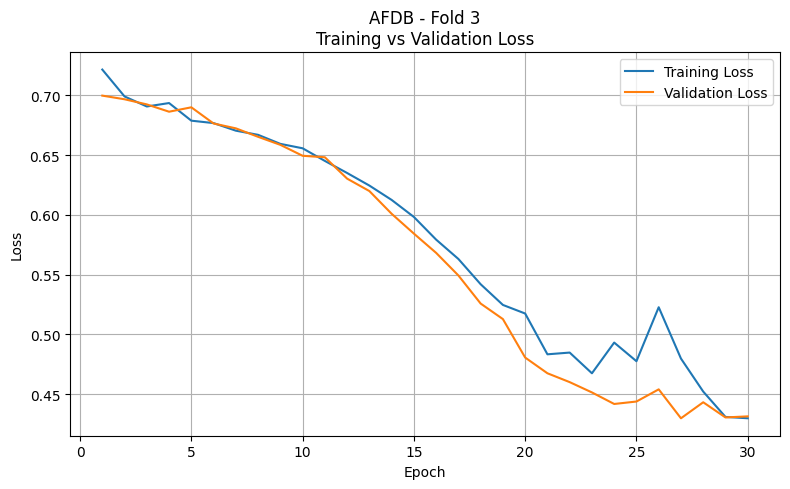


AFDB - FOLD 4
Model creation time: 0.0165 seconds
Fold 4 | Epoch [1/30] | Train Loss: 0.7101 | Val Loss: 0.7107 | Train Acc: 0.4217 | Val Acc: 0.5057
Fold 4 | Epoch [2/30] | Train Loss: 0.7010 | Val Loss: 0.7004 | Train Acc: 0.4644 | Val Acc: 0.4943
Fold 4 | Epoch [3/30] | Train Loss: 0.6935 | Val Loss: 0.6920 | Train Acc: 0.5100 | Val Acc: 0.5862
Fold 4 | Epoch [4/30] | Train Loss: 0.6901 | Val Loss: 0.6874 | Train Acc: 0.4957 | Val Acc: 0.5172
Fold 4 | Epoch [5/30] | Train Loss: 0.6835 | Val Loss: 0.6872 | Train Acc: 0.5926 | Val Acc: 0.4943
Fold 4 | Epoch [6/30] | Train Loss: 0.6817 | Val Loss: 0.6750 | Train Acc: 0.5271 | Val Acc: 0.6437
Fold 4 | Epoch [7/30] | Train Loss: 0.6773 | Val Loss: 0.6754 | Train Acc: 0.6011 | Val Acc: 0.5632
Fold 4 | Epoch [8/30] | Train Loss: 0.6685 | Val Loss: 0.6618 | Train Acc: 0.6553 | Val Acc: 0.7011
Fold 4 | Epoch [9/30] | Train Loss: 0.6627 | Val Loss: 0.6551 | Train Acc: 0.6524 | Val Acc: 0.6782
Fold 4 | Epoch [10/30] | Train Loss: 0.6578 | Val

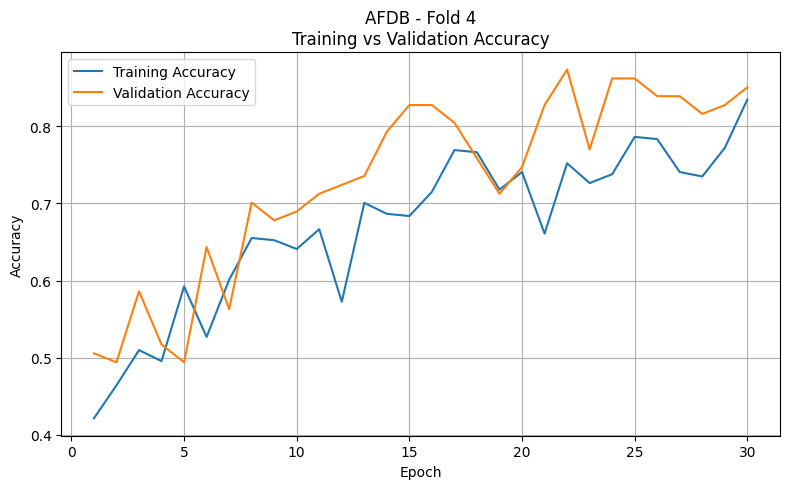

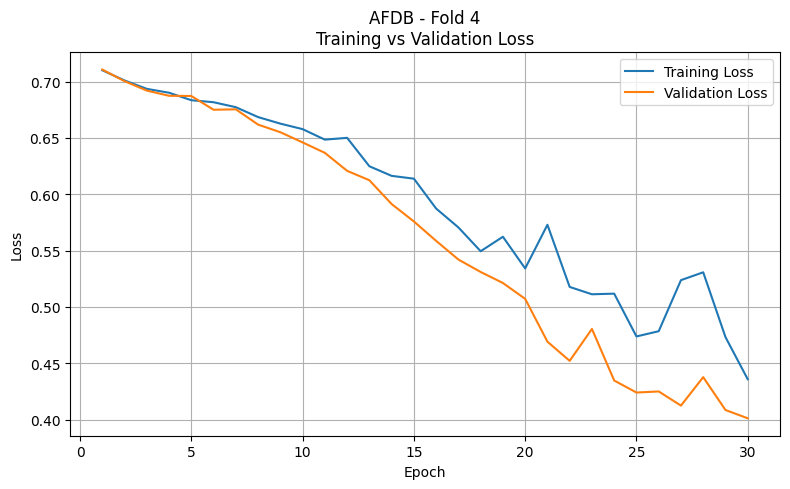


AFDB - FOLD 5
Model creation time: 0.0161 seconds
Fold 5 | Epoch [1/30] | Train Loss: 0.7153 | Val Loss: 0.7269 | Train Acc: 0.4986 | Val Acc: 0.5057
Fold 5 | Epoch [2/30] | Train Loss: 0.6910 | Val Loss: 0.7021 | Train Acc: 0.5128 | Val Acc: 0.5057
Fold 5 | Epoch [3/30] | Train Loss: 0.6845 | Val Loss: 0.6998 | Train Acc: 0.5755 | Val Acc: 0.5057
Fold 5 | Epoch [4/30] | Train Loss: 0.6812 | Val Loss: 0.6939 | Train Acc: 0.5584 | Val Acc: 0.5402
Fold 5 | Epoch [5/30] | Train Loss: 0.6754 | Val Loss: 0.6882 | Train Acc: 0.5499 | Val Acc: 0.5172
Fold 5 | Epoch [6/30] | Train Loss: 0.6703 | Val Loss: 0.7201 | Train Acc: 0.5812 | Val Acc: 0.5057
Fold 5 | Epoch [7/30] | Train Loss: 0.6661 | Val Loss: 0.6893 | Train Acc: 0.6068 | Val Acc: 0.5287
Fold 5 | Epoch [8/30] | Train Loss: 0.6589 | Val Loss: 0.7031 | Train Acc: 0.5926 | Val Acc: 0.5517
Fold 5 | Epoch [9/30] | Train Loss: 0.6471 | Val Loss: 0.6876 | Train Acc: 0.6695 | Val Acc: 0.5287
Fold 5 | Epoch [10/30] | Train Loss: 0.6413 | Val

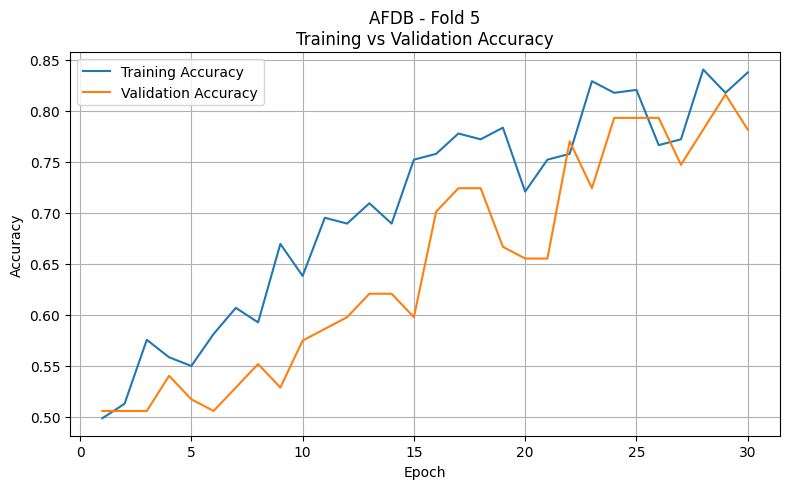

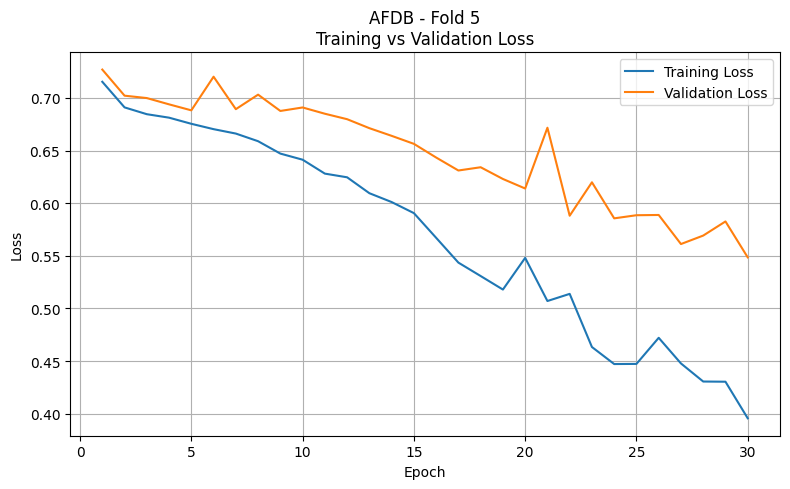



########################################
BEST FOLD
########################################
Best Fold              : 4
Best Validation Acc    : 0.8736
Best Epoch             : 22


########################################
FINAL TEST
########################################

Best Fold = 4
Accuracy     : 0.7909
Recall       : 0.7909
F1-score     : 0.7908
Specificity  : 0.7909
ROC-AUC      : 0.8489


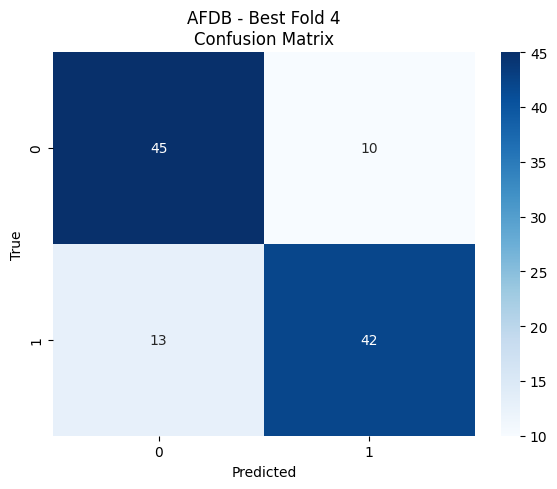



########################################
DATASET: VFDB
########################################
Training + CV data : 156
Test data          : 40

VFDB - FOLD 1
Model creation time: 0.0108 seconds
Fold 1 | Epoch [1/30] | Train Loss: 0.8141 | Val Loss: 0.7517 | Train Acc: 0.5000 | Val Acc: 0.5000
Fold 1 | Epoch [2/30] | Train Loss: 0.7662 | Val Loss: 0.7294 | Train Acc: 0.5000 | Val Acc: 0.5000
Fold 1 | Epoch [3/30] | Train Loss: 0.7212 | Val Loss: 0.7028 | Train Acc: 0.5081 | Val Acc: 0.5000
Fold 1 | Epoch [4/30] | Train Loss: 0.6889 | Val Loss: 0.6753 | Train Acc: 0.5000 | Val Acc: 0.5000
Fold 1 | Epoch [5/30] | Train Loss: 0.6648 | Val Loss: 0.6532 | Train Acc: 0.5403 | Val Acc: 0.5000
Fold 1 | Epoch [6/30] | Train Loss: 0.6537 | Val Loss: 0.6386 | Train Acc: 0.6210 | Val Acc: 0.5312
Fold 1 | Epoch [7/30] | Train Loss: 0.6446 | Val Loss: 0.6320 | Train Acc: 0.7016 | Val Acc: 0.7500
Fold 1 | Epoch [8/30] | Train Loss: 0.6380 | Val Loss: 0.6312 | Train Acc: 0.7339 | Val Acc: 0.6875
Fo

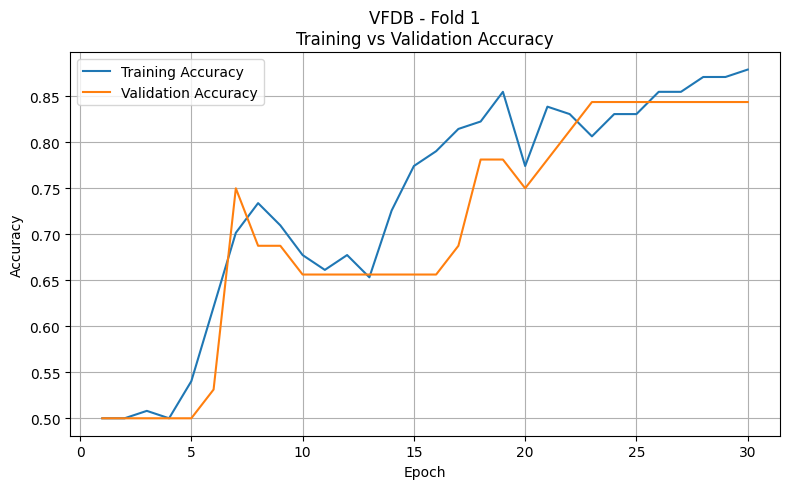

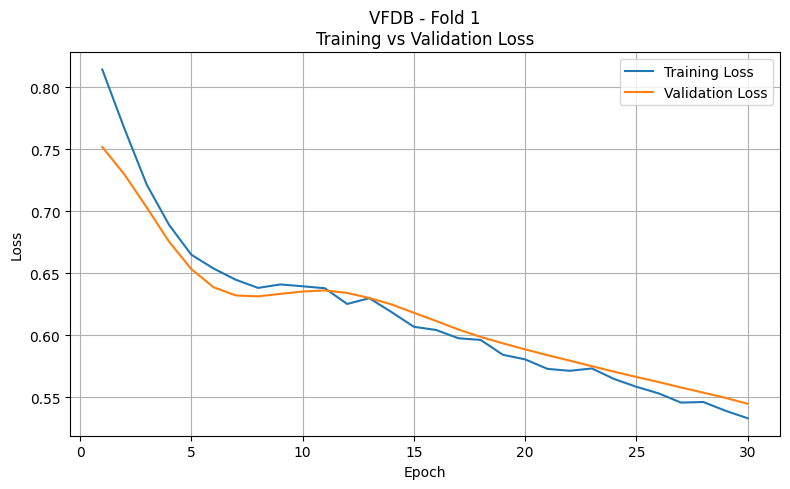


VFDB - FOLD 2
Model creation time: 0.0167 seconds
Fold 2 | Epoch [1/30] | Train Loss: 0.7251 | Val Loss: 0.7872 | Train Acc: 0.2320 | Val Acc: 0.4516
Fold 2 | Epoch [2/30] | Train Loss: 0.7183 | Val Loss: 0.7850 | Train Acc: 0.2880 | Val Acc: 0.4516
Fold 2 | Epoch [3/30] | Train Loss: 0.7114 | Val Loss: 0.7634 | Train Acc: 0.4000 | Val Acc: 0.4516
Fold 2 | Epoch [4/30] | Train Loss: 0.6982 | Val Loss: 0.7362 | Train Acc: 0.5440 | Val Acc: 0.4516
Fold 2 | Epoch [5/30] | Train Loss: 0.6909 | Val Loss: 0.7127 | Train Acc: 0.6160 | Val Acc: 0.4839
Fold 2 | Epoch [6/30] | Train Loss: 0.6808 | Val Loss: 0.6942 | Train Acc: 0.6960 | Val Acc: 0.5161
Fold 2 | Epoch [7/30] | Train Loss: 0.6717 | Val Loss: 0.6799 | Train Acc: 0.7600 | Val Acc: 0.5806
Fold 2 | Epoch [8/30] | Train Loss: 0.6653 | Val Loss: 0.6692 | Train Acc: 0.7280 | Val Acc: 0.6452
Fold 2 | Epoch [9/30] | Train Loss: 0.6560 | Val Loss: 0.6605 | Train Acc: 0.7760 | Val Acc: 0.7097
Fold 2 | Epoch [10/30] | Train Loss: 0.6561 | Val

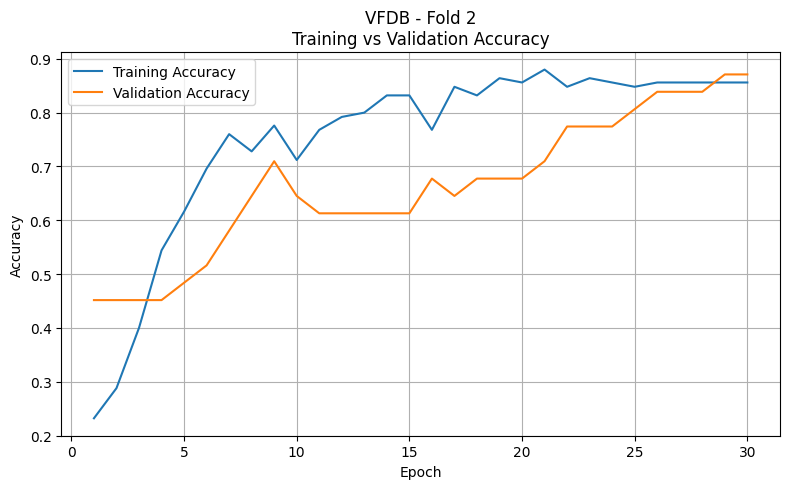

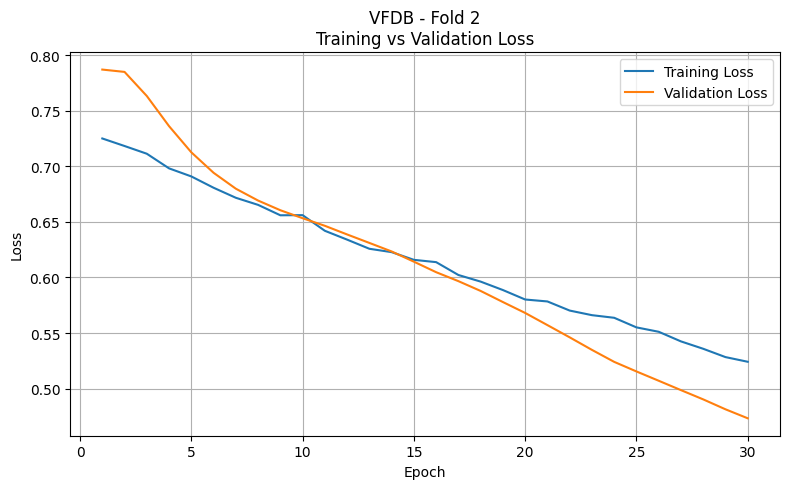


VFDB - FOLD 3
Model creation time: 0.0173 seconds
Fold 3 | Epoch [1/30] | Train Loss: 0.7095 | Val Loss: 0.7450 | Train Acc: 0.3680 | Val Acc: 0.5161
Fold 3 | Epoch [2/30] | Train Loss: 0.6986 | Val Loss: 0.7424 | Train Acc: 0.5360 | Val Acc: 0.4839
Fold 3 | Epoch [3/30] | Train Loss: 0.6883 | Val Loss: 0.7373 | Train Acc: 0.6000 | Val Acc: 0.4839
Fold 3 | Epoch [4/30] | Train Loss: 0.6780 | Val Loss: 0.7285 | Train Acc: 0.5840 | Val Acc: 0.4839
Fold 3 | Epoch [5/30] | Train Loss: 0.6674 | Val Loss: 0.7194 | Train Acc: 0.6240 | Val Acc: 0.4839
Fold 3 | Epoch [6/30] | Train Loss: 0.6576 | Val Loss: 0.7107 | Train Acc: 0.7040 | Val Acc: 0.4516
Fold 3 | Epoch [7/30] | Train Loss: 0.6473 | Val Loss: 0.7022 | Train Acc: 0.7680 | Val Acc: 0.4194
Fold 3 | Epoch [8/30] | Train Loss: 0.6405 | Val Loss: 0.6943 | Train Acc: 0.7760 | Val Acc: 0.4194
Fold 3 | Epoch [9/30] | Train Loss: 0.6286 | Val Loss: 0.6877 | Train Acc: 0.8400 | Val Acc: 0.5161
Fold 3 | Epoch [10/30] | Train Loss: 0.6222 | Val

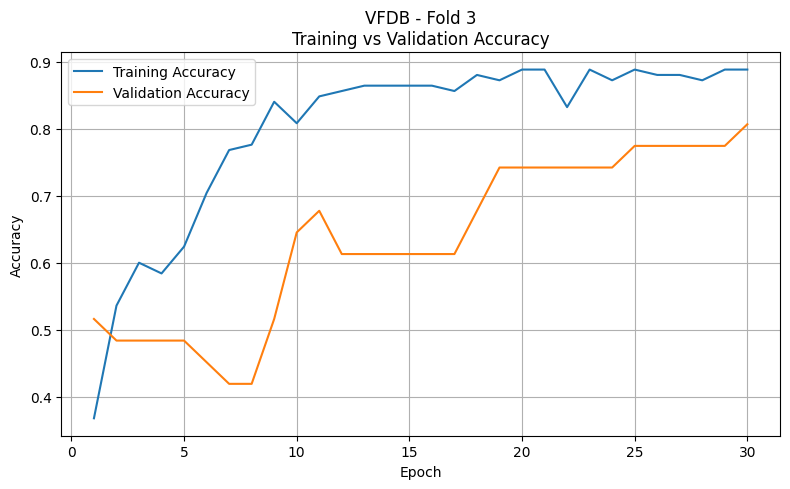

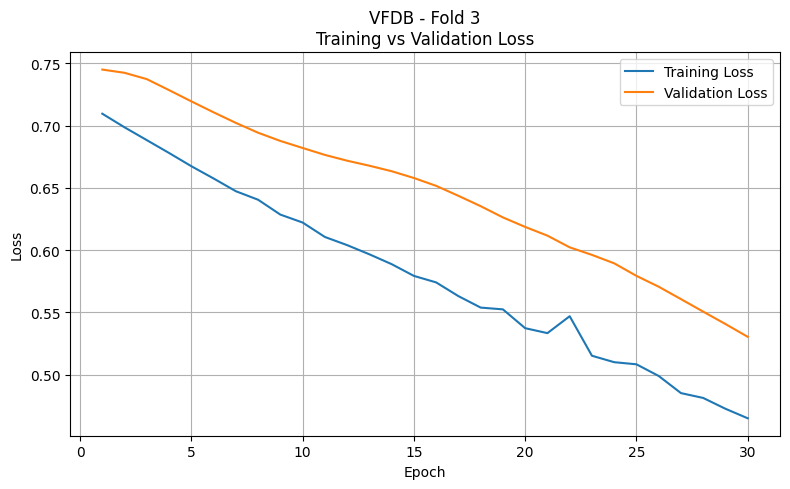


VFDB - FOLD 4
Model creation time: 0.0213 seconds
Fold 4 | Epoch [1/30] | Train Loss: 0.6759 | Val Loss: 0.8395 | Train Acc: 0.5280 | Val Acc: 0.4839
Fold 4 | Epoch [2/30] | Train Loss: 0.6626 | Val Loss: 0.8052 | Train Acc: 0.5760 | Val Acc: 0.4839
Fold 4 | Epoch [3/30] | Train Loss: 0.6500 | Val Loss: 0.7657 | Train Acc: 0.6320 | Val Acc: 0.4516
Fold 4 | Epoch [4/30] | Train Loss: 0.6371 | Val Loss: 0.7328 | Train Acc: 0.7840 | Val Acc: 0.4516
Fold 4 | Epoch [5/30] | Train Loss: 0.6330 | Val Loss: 0.7132 | Train Acc: 0.8080 | Val Acc: 0.3871
Fold 4 | Epoch [6/30] | Train Loss: 0.6199 | Val Loss: 0.7020 | Train Acc: 0.8320 | Val Acc: 0.4516
Fold 4 | Epoch [7/30] | Train Loss: 0.6134 | Val Loss: 0.6955 | Train Acc: 0.8400 | Val Acc: 0.6129
Fold 4 | Epoch [8/30] | Train Loss: 0.6025 | Val Loss: 0.6916 | Train Acc: 0.8320 | Val Acc: 0.5484
Fold 4 | Epoch [9/30] | Train Loss: 0.5972 | Val Loss: 0.6884 | Train Acc: 0.8240 | Val Acc: 0.5806
Fold 4 | Epoch [10/30] | Train Loss: 0.5976 | Val

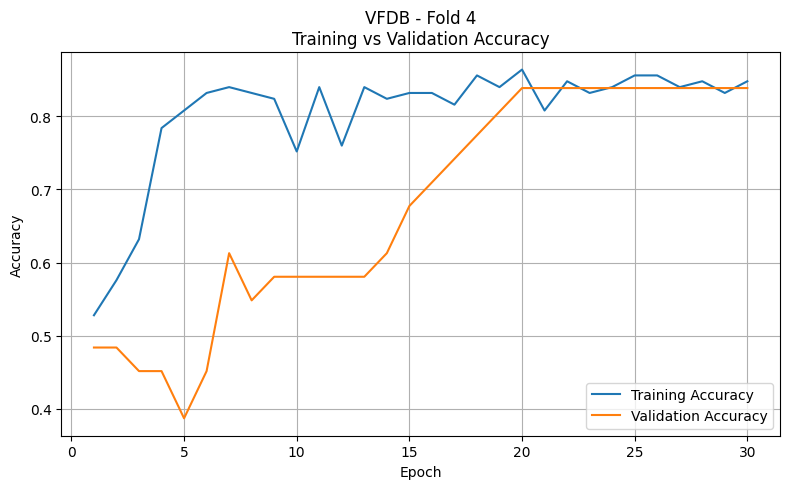

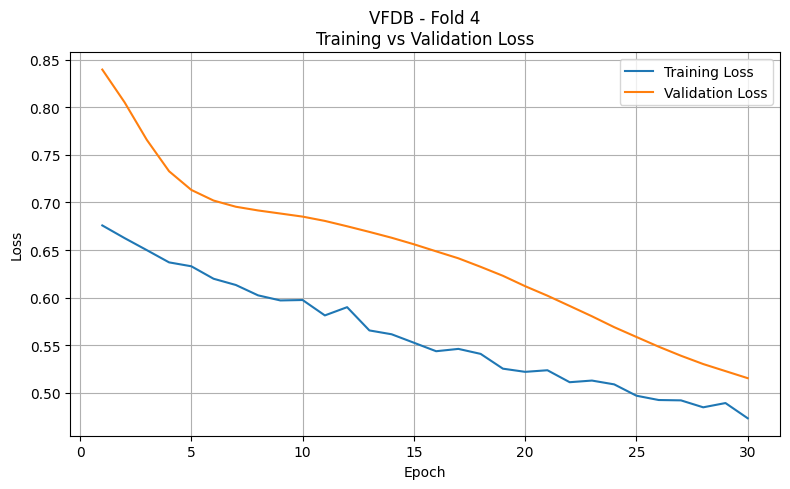


VFDB - FOLD 5
Model creation time: 0.0167 seconds
Fold 5 | Epoch [1/30] | Train Loss: 0.6946 | Val Loss: 0.6953 | Train Acc: 0.5520 | Val Acc: 0.5161
Fold 5 | Epoch [2/30] | Train Loss: 0.6775 | Val Loss: 0.6911 | Train Acc: 0.6160 | Val Acc: 0.5161
Fold 5 | Epoch [3/30] | Train Loss: 0.6682 | Val Loss: 0.6863 | Train Acc: 0.7280 | Val Acc: 0.5161
Fold 5 | Epoch [4/30] | Train Loss: 0.6658 | Val Loss: 0.6797 | Train Acc: 0.7680 | Val Acc: 0.5484
Fold 5 | Epoch [5/30] | Train Loss: 0.6573 | Val Loss: 0.6732 | Train Acc: 0.7200 | Val Acc: 0.5484
Fold 5 | Epoch [6/30] | Train Loss: 0.6535 | Val Loss: 0.6665 | Train Acc: 0.7280 | Val Acc: 0.5484
Fold 5 | Epoch [7/30] | Train Loss: 0.6471 | Val Loss: 0.6607 | Train Acc: 0.7200 | Val Acc: 0.5806
Fold 5 | Epoch [8/30] | Train Loss: 0.6419 | Val Loss: 0.6553 | Train Acc: 0.7120 | Val Acc: 0.5806
Fold 5 | Epoch [9/30] | Train Loss: 0.6352 | Val Loss: 0.6499 | Train Acc: 0.7440 | Val Acc: 0.6129
Fold 5 | Epoch [10/30] | Train Loss: 0.6274 | Val

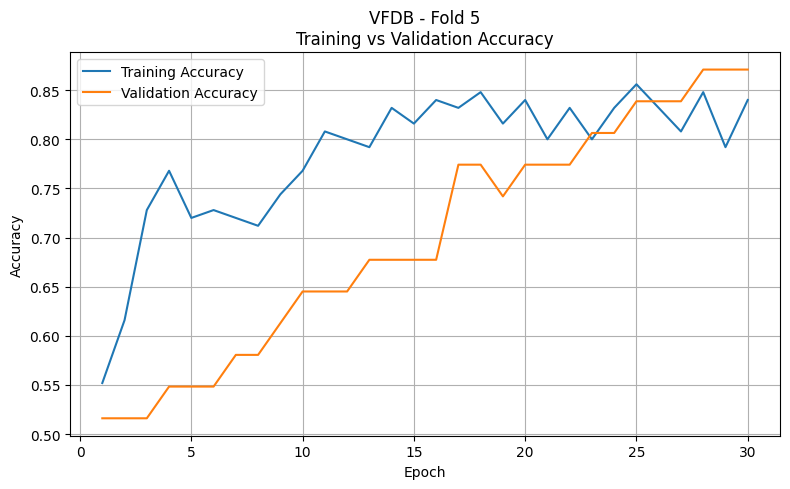

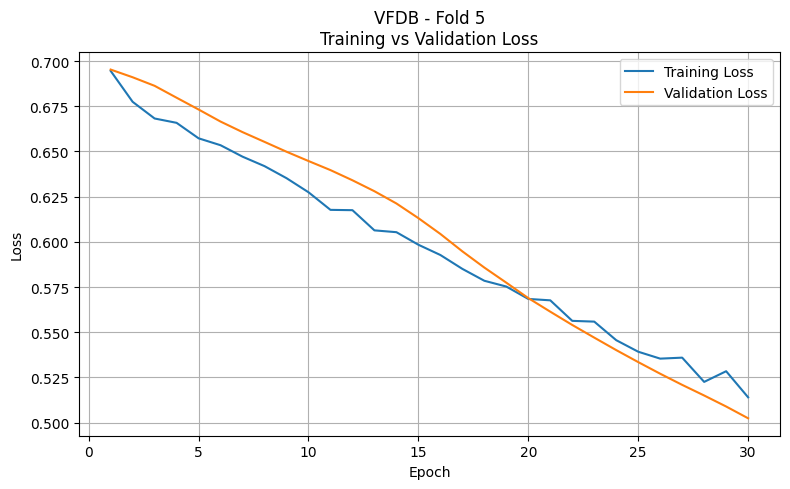



########################################
BEST FOLD
########################################
Best Fold              : 2
Best Validation Acc    : 0.8710
Best Epoch             : 29


########################################
FINAL TEST
########################################

Best Fold = 2
Accuracy     : 0.8750
Recall       : 0.8750
F1-score     : 0.8749
Specificity  : 0.8750
ROC-AUC      : 0.8900


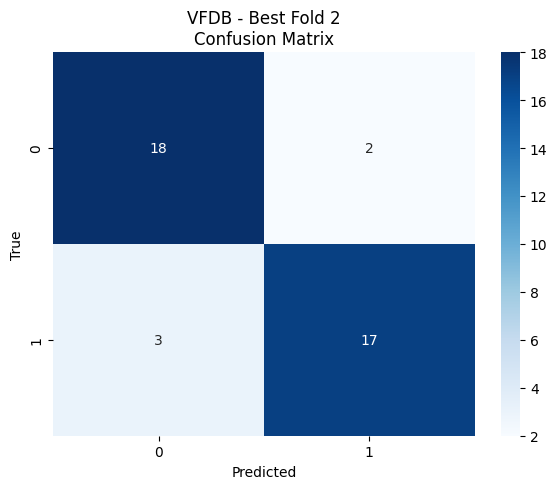

{'best_fold': 2,
 'best_val_acc': 0.8709677419354839,
 'test_accuracy': 0.875,
 'test_recall': 0.875,
 'test_f1': 0.8749218261413383,
 'test_specificity': 0.875,
 'test_auc': np.float64(0.89)}

In [19]:
# MITDB

X_mit, y_mit = load_mitdb()
X_mit, y_mit = balance_classes(X_mit, y_mit)
train_and_evaluate(X_mit, y_mit, "MITDB")

# AFDB

X_af, y_af = load_afdb()
X_af, y_af = balance_classes(X_af, y_af)
train_and_evaluate(X_af, y_af, "AFDB")

# VFDB

X_vf, y_vf = load_vfdb()
X_vf, y_vf = balance_classes(X_vf, y_vf)
train_and_evaluate(X_vf, y_vf, "VFDB")
